<a href="https://colab.research.google.com/github/abbiddo/retention-analysis/blob/main/student_retention_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monthly Retention Analysis

운영 데이터 기반 재수강률 추이 분석

목표:
- 월별 재수강률 변화 확인
- 상품/학년/담당자별 차이 탐색
- 운영 KPI 흐름 분석

# 데이터 불러오기

In [1]:
# google 계정 연동

from google.colab import auth
auth.authenticate_user()

In [2]:
# drive mount

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 결제 내역 데이터 불러오기

import pandas as pd
from datetime import datetime

today = datetime.today().date()
today = str(today)
today = today[:4]+'_'+today[5:7]+'_'+today[8:]
print(today)

file_name = "payment_data_" + today + '.csv'
print(file_name)

# 경로명 변경 ----------------------------------------------------
file_path = "/content/drive/MyDrive/analyze/data/" + file_name

df = pd.read_csv(file_path, encoding="utf-8-sig")

#df.head()
#df.columns

# 전처리

## Dataset

- 분석 기간: 2024-04 ~ 2026-04
- 기준 데이터: 계산일 기준 운영 데이터
- 주요 컬럼:
    - 계약상태
    - 상품명
    - 학년
    - 담당부서
    - 담당자

In [23]:
# 필요한 컬럼 선별
df = df[['계약상태', '상품명', '신규/재연장', '학년', 'subject', '계산일', '선생님', '담당부서', '개강전환불']]

# df.head()

In [26]:
# 수학 정규 결제만

df = df[df['subject'].isin(['수학'])]

In [27]:
# 계약상태 이상치 제외

exclude = ['취소', '폐지', '수능', '수시']
pattern = '|'.join(exclude)

df = df[df['개강전환불'] != 1]
df = df[~df['계약상태'].str.contains(pattern, na=True)]

In [28]:
# 상품명 이상치 제외

exclude_products = ['무료', 'VIP', '유튜브']
pattern = '|'.join(exclude_products)

df = df[~df['상품명'].str.contains(pattern, na=True)]

In [29]:
# 월 별 데이터 수치 확인
df['월'] = pd.to_datetime(df['계산일']).dt.strftime('%y-%m')

df_month_size = df.groupby('월').size()
#df_month_size

In [30]:
# 데이터 안정화 이전(~24-03) 및 미완료 월(26-05~) 제외

df = df[(df['월'] >= '24-04') & (df['월'] <= '26-04')]

# Analysis 1. 월별 재수강률 추이

가설:
- 학사 일정 및 시즌에 따라 재수강률 차이가 존재할 수 있음

확인 항목:
- 월별 재수강률 변화
- 특정 기간 상승/하락 패턴 존재 여부

In [32]:
df_month = df
df_month['연장여부'] = (df_month['계약상태'].isin(['연장완료', '전환_미연장', '전환_환불'])).astype(int)

df_monthly = df_month.groupby('월').agg(
    전체건수=('계약상태', 'count'),
    연장완료=('연장여부', 'sum')
).reset_index()

df_monthly['재수강률'] = (df_monthly['연장완료'] / df_monthly['전체건수'] * 100).round(1)

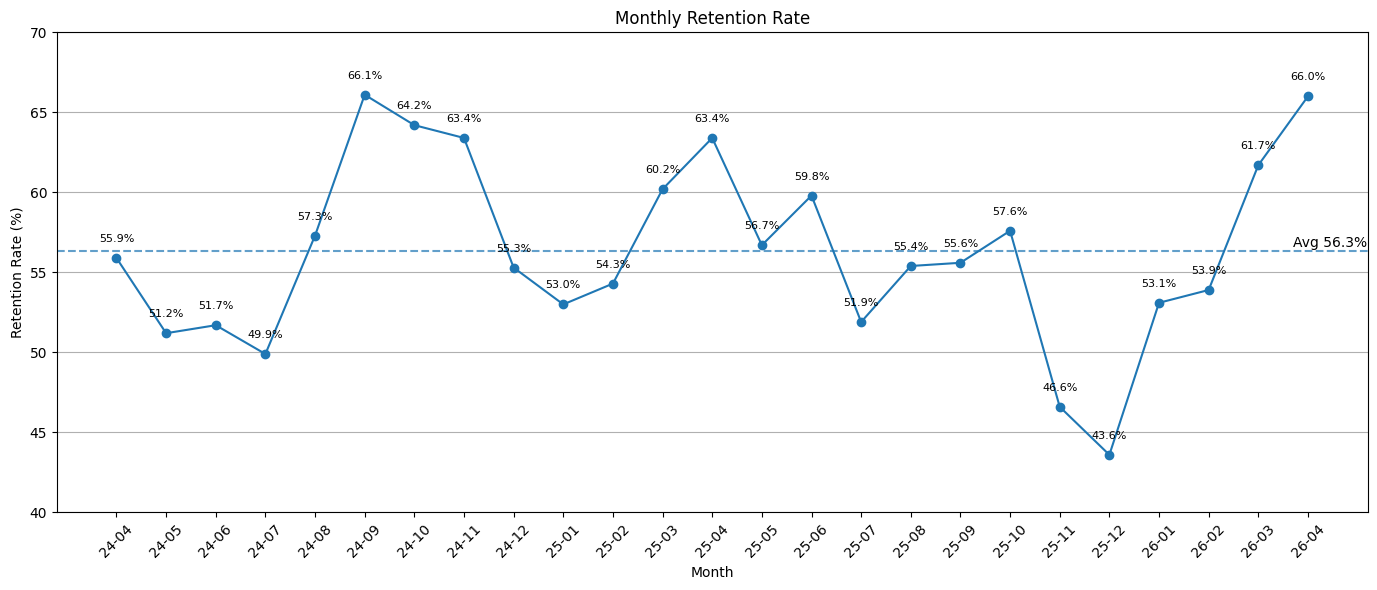

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df_monthly['월'],
    df_monthly['재수강률'],
    marker='o'
)

plt.title('Monthly Retention Rate')
plt.xlabel('Month')
plt.ylabel('Retention Rate (%)')

plt.ylim(40, 70)
plt.xticks(rotation=45)
plt.grid(axis = 'y')

# 데이터 값 표시
for i, value in enumerate(df_monthly['재수강률']):
    plt.text(i,
    value + 1,
    f'{value:.1f}%',
    ha='center',
    fontsize=8
)

# 평균선 추가
avg_rate = df_monthly['재수강률'].mean()

plt.axhline(
    avg_rate,
    linestyle='--',
    alpha=0.7
)

plt.text(
    len(df_monthly)-1.3,
    avg_rate + 0.3,
    f'Avg {avg_rate:.1f}%'
)

plt.tight_layout()

plt.show()

## Observation

- 전체 평균 재수강률: 약 56.3%
- 학기 중 상승, 방학 중 하락 패턴을 가설로 세웠으나 연도별로 일관되지 않음
- 월별 변동폭이 비교적 크게 나타났으며, 특정 시기 재수강률 하락 구간도 확인됨
- 단순 계절성만으로 설명되지 않는 흐름 존재
- 단순 계절성 외 복합 요인 가능성 → 팀원별/상품별 분석으로 원인 탐색

